<a href="https://colab.research.google.com/github/Shivabairy005/Deep-Learning-Lab/blob/main/DL_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

gd Accuracy: 100.0
momentum Accuracy: 100.0
adam Accuracy: 100.0


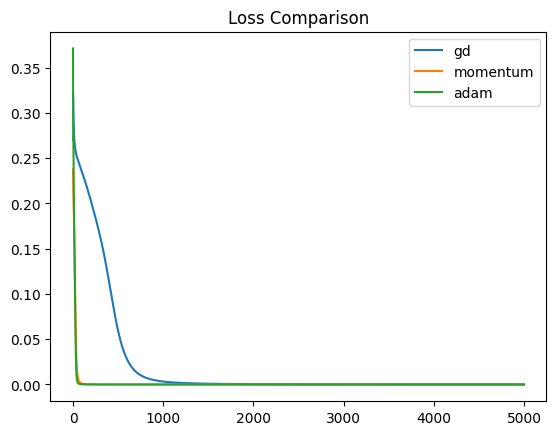

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

def sigmoid(n):
    return 1 / (1 + np.exp(-n))

def sigmoid_derivative(n):
    return n * (1 - n)

def tanh(n):
    return np.tanh(n)

def tanh_derivative(n):
    return 1 - np.tanh(n) ** 2

class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.w1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.w2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, n):
        self.z1 = np.dot(n, self.w1) + self.b1
        self.a1 = tanh(self.z1)
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        dz2 = self.a2 - y
        dw2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        dz1 = np.dot(dz2, self.w2.T) * tanh_derivative(self.z1)
        dw1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        return dw1, db1, dw2, db2

def update_gd(model, grads, lr):
    dw1, db1, dw2, db2 = grads
    model.w1 -= lr * dw1
    model.b1 -= lr * db1
    model.w2 -= lr * dw2
    model.b2 -= lr * db2

def update_momentum(model, grads, lr, velocity, beta=0.9):
    dw1, db1, dw2, db2 = grads
    velocity["dw1"] = beta * velocity["dw1"] + lr * dw1
    velocity["db1"] = beta * velocity["db1"] + lr * db1
    velocity["dw2"] = beta * velocity["dw2"] + lr * dw2
    velocity["db2"] = beta * velocity["db2"] + lr * db2
    model.w1 -= velocity["dw1"]
    model.b1 -= velocity["db1"]
    model.w2 -= velocity["dw2"]
    model.b2 -= velocity["db2"]

def update_adam(model, grads, adam_params, lr, t, beta1=0.9, beta2=0.999, ep=1e-8):
    dw1, db1, dw2, db2 = grads

    for key, grad in zip(["w1", "b1", "w2", "b2"], [dw1, db1, dw2, db2]):
        adam_params["m_" + key] = beta1 * adam_params["m_" + key] + (1 - beta1) * grad
        adam_params["v_" + key] = beta2 * adam_params["v_" + key] + (1 - beta2) * (grad ** 2)

        m_hat = adam_params["m_" + key] / (1 - beta1 ** t)
        v_hat = adam_params["v_" + key] / (1 - beta2 ** t)

        setattr(model, key, getattr(model, key) - lr * m_hat / (np.sqrt(v_hat) + ep))

def train(model, X, y, optimizer="gd", lr=0.1, epochs=5000):
    losses = []

    velocity = {
        "dw1": np.zeros_like(model.w1),
        "db1": np.zeros_like(model.b1),
        "dw2": np.zeros_like(model.w2),
        "db2": np.zeros_like(model.b2)
    }

    adam_params = {
        "m_w1": np.zeros_like(model.w1),
        "v_w1": np.zeros_like(model.w1),
        "m_b1": np.zeros_like(model.b1),
        "v_b1": np.zeros_like(model.b1),
        "m_w2": np.zeros_like(model.w2),
        "v_w2": np.zeros_like(model.w2),
        "m_b2": np.zeros_like(model.b2),
        "v_b2": np.zeros_like(model.b2)
    }

    for epoch in range(1, epochs + 1):
        output = model.forward(X)
        loss = np.mean((y - output) ** 2)
        losses.append(loss)

        grads = model.backward(X, y)

        if optimizer == "gd":
            update_gd(model, grads, lr)
        elif optimizer == "momentum":
            update_momentum(model, grads, lr, velocity)
        elif optimizer == "adam":
            update_adam(model, grads, adam_params, lr, epoch)

    return losses

optimizers = ["gd", "momentum", "adam"]
results = {}

for opt in optimizers:
    model = MLP(2, 4, 1)
    losses = train(model, X, y, optimizer=opt)
    results[opt] = losses

    predictions = model.forward(X)
    predicted = (predictions > 0.5).astype(int)
    accuracy = np.mean(predicted == y)
    print(opt, "Accuracy:", accuracy * 100)

for opt in optimizers:
    plt.plot(results[opt], label=opt)

plt.legend()
plt.title("Loss Comparison")
plt.show()